<a href="https://colab.research.google.com/github/Ayon150/AI_-_DL/blob/main/DL_ASSIGNMENT_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=128,
                                         shuffle=False, num_workers=2)

HTTPError: HTTP Error 503: Service Unavailable

In [5]:
import torch
import numpy as np
from tensorflow.keras.datasets import cifar10

# Load from TensorFlow (Google-hosted, stable)
(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# Convert to PyTorch format (N, C, H, W)
x_train = torch.tensor(x_train).permute(0, 3, 1, 2)
x_test = torch.tensor(x_test).permute(0, 3, 1, 2)

# Create DataLoader
trainloader = torch.utils.data.DataLoader(x_train, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(x_test, batch_size=128, shuffle=False)

print("Dataset loaded successfully!")

Exception: URL fetch failure on https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz: 503 -- Service Unavailable

In [6]:
!pip install datasets

In [7]:
from datasets import load_dataset

# Load CIFAR-10 from Hugging Face (no Toronto server!)
dataset = load_dataset("cifar10")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [8]:
import tensorflow as tf
import numpy as np

def preprocess(example):
    image = np.array(example['img']) / 255.0
    return image.astype("float32")

# Convert dataset
x_train = np.stack([preprocess(x) for x in dataset['train']])
x_test  = np.stack([preprocess(x) for x in dataset['test']])

print(x_train.shape, x_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3)


In [9]:
def add_gaussian_noise(x, std=0.2):
    noise = np.random.normal(0, std, x.shape)
    noisy = x + noise
    return np.clip(noisy, 0., 1.)

def add_salt_pepper_noise(x, prob=0.1):
    noisy = x.copy()
    rand = np.random.rand(*x.shape)

    noisy[rand < prob/2] = 0
    noisy[rand > 1 - prob/2] = 1

    return noisy

In [10]:
from tensorflow.keras import layers, models

def build_dae_transpose():
    input_img = layers.Input(shape=(32,32,3))

    # Encoder
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(input_img)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)

    # Decoder
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(3, 3, strides=2, padding='same', activation='sigmoid')(x)

    model = models.Model(input_img, x)
    model.compile(optimizer='adam', loss='mse')
    return model

In [11]:
def build_dae_upsample():
    input_img = layers.Input(shape=(32,32,3))

    # Encoder
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(input_img)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    # Decoder
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(3, 3, padding='same', activation='sigmoid')(x)

    model = models.Model(input_img, x)
    model.compile(optimizer='adam', loss='mse')
    return model

In [12]:
# Add noise
x_train_noisy = add_gaussian_noise(x_train, std=0.2)
x_test_noisy  = add_gaussian_noise(x_test, std=0.2)

model = build_dae_transpose()

history = model.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0140 - val_loss: 0.0069
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0064 - val_loss: 0.0059
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0055 - val_loss: 0.0054
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0051 - val_loss: 0.0050
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0050 - val_loss: 0.0051
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0048 - val_loss: 0.0047
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0048 - val_loss: 0.0047
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0047 - val_loss: 0.0047
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0047 - val_loss: 0.0046


In [13]:
def psnr(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    return 20 * np.log10(1.0 / np.sqrt(mse))

denoised = model.predict(x_test_noisy[:100])
print("PSNR:", psnr(x_test[:100], denoised))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step
PSNR: 23.263447


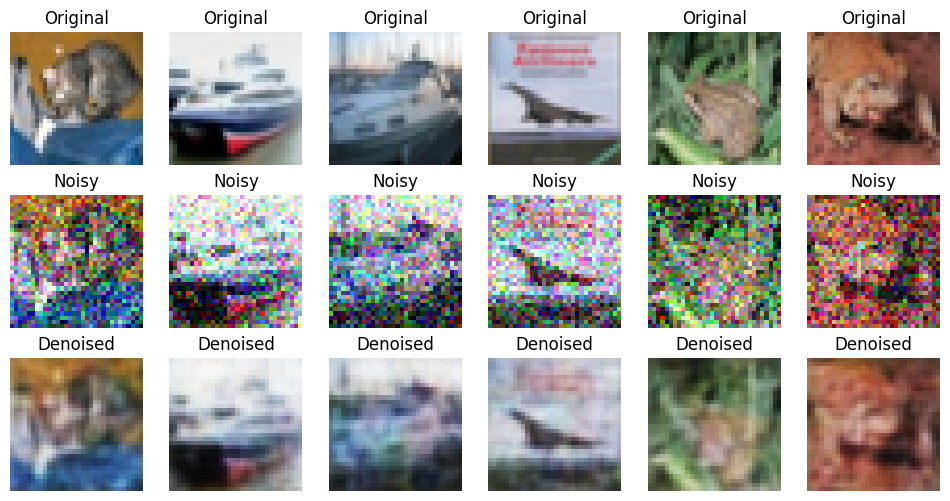

In [14]:
import matplotlib.pyplot as plt

n = 6
plt.figure(figsize=(12,6))

for i in range(n):
    # original
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")

    # noisy
    ax = plt.subplot(3, n, i+n+1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    plt.axis("off")

    # denoised
    ax = plt.subplot(3, n, i+2*n+1)
    plt.imshow(denoised[i])
    plt.title("Denoised")
    plt.axis("off")

plt.show()